# **Experiment 1 Notebook**



---
## Setup Environment

In [125]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



You can now save your data files in: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [126]:
# <Student to fill this section>
student_name = "Aryan Goel"
student_id = "26040826"

In [127]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [128]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [129]:
# <Student to fill this section>

### 0.b Import Packages

In [130]:
# 0.b imports
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

sns.set(style="whitegrid")
alt.data_transformers.disable_max_rows()
RANDOM_STATE = 42
target_name = "disease_diagnosis"

---
## A. Experiment Description

In [131]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "1"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [132]:
# experiment_hypothesis
experiment_hypothesis = """
Hypothesis: A non-linear tree-based model (Random Forest) will significantly outperform the Dummy Classifier baseline on multiclass vitamin-deficiency diagnosis, especially on macro-F1 and balanced accuracy.

Reasoning:
1) Clinical + lifestyle relationships are likely non-linear and interaction-heavy.
2) Random Forest can capture interaction effects without manual feature crosses.
3) Class imbalance can be partially addressed with class_weight='balanced'.
4) This experiment tests whether moving from a naive baseline to non-linear modeling improves class-wise fairness and minority-class recognition.
"""

In [133]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [134]:
experiment_expectations = """
Expected outcome:
- Massive improvement over baseline Dummy Classifier metrics (baseline test approx: accuracy 0.364, balanced_accuracy 0.200, macro_f1 0.107).
- Target uplift goal for this experiment:
  * macro_f1: +0.60 to +0.70
  * balanced_accuracy: +0.50 to +0.60

Possible scenarios:
1) Strong improvement: RF clearly outperforms baseline on macro_f1 and balanced_accuracy.
2) Partial improvement: RF improves one key metric but not all.
3) No improvement: RF overfits or fails to generalize, suggesting need for tuning/feature refinement.
"""

In [135]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [136]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

---
## D. Feature Selection


In [137]:
# Keep all prepared features for controlled comparison with baseline
if isinstance(y_train, pd.DataFrame): y_train = y_train.iloc[:, 0]
if isinstance(y_val, pd.DataFrame): y_val = y_val.iloc[:, 0]
if isinstance(y_test, pd.DataFrame): y_test = y_test.iloc[:, 0]

features_list = X_train.columns.tolist()

print(f"Selected features: {len(features_list)}")
print("Sample feature names:", features_list[:10])

Selected features: 80
Sample feature names: ['age', 'postcode', 'bmi', 'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake', 'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake', 'calcium_intake']


In [138]:
feature_selection_explanations = """
All features produced by the Preparation notebook are retained for Experiment 1 to ensure consistency with the validated preprocessing pipeline.

Rationale:
- Preparation already applied privacy-safe filtering, missing-value handling, encoding, and scaling.
- Using the full prepared matrix avoids introducing uncontrolled selection bias in the first experiment.
- Random Forest can internally down-weight weak predictors via split quality, making full-feature evaluation appropriate as an initial non-linear benchmark.
- This approach provides a robust first non-linear benchmark before conducting stricter feature pruning in later experiments.
"""

In [139]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation "Data Transformation - y fix + safety checks"


In [140]:
# E.1 Data Transformation - y fix + safety checks
# Convert y to 1D series if needed
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]
if isinstance(y_val, pd.DataFrame):
    y_val = y_val.iloc[:, 0]
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0]

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val:", y_val.shape)
print("X_test :", X_test.shape, "y_test:", y_test.shape)

print("\nNaN checks:")
print("X:", X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum())
print("y:", y_train.isna().sum(), y_val.isna().sum(), y_test.isna().sum())

print("\nNaN checks (before coercion):")
print("X_train:", X_train.isna().sum().sum())
print("X_val  :", X_val.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_val  :", y_val.isna().sum())
print("y_test :", y_test.isna().sum())

Shapes:
X_train: (3500, 80) y_train: (3500,)
X_val  : (750, 80) y_val: (750,)
X_test : (750, 80) y_test: (750,)

NaN checks:
X: 0 0 0
y: 0 0 0

NaN checks (before coercion):
X_train: 0
X_val  : 0
X_test : 0
y_train: 0
y_val  : 0
y_test : 0


In [141]:
# data_transformation_1_explanations
data_transformation_1_explanations = """
The first preparation step verifies model inputs are valid and leakage-safe:
- target vectors converted to 1D class labels,
- dataset shape consistency confirmed,
- missing-value checks performed on all splits.

This is essential to prevent silent training errors and ensure fair experiment comparison with baseline results.
This experiment uses the prepared feature matrix directly (no synthetic resampling).
The objective is to isolate model-family impact by testing Random Forest on the same split used in baseline.
This keeps the comparison fair and avoids introducing additional variance from resampling.
"""

In [142]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### E.2 Data Transformation "Class Distribution Audit"


In [143]:
# Ensure fully numeric feature matrix for sklearn estimators
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_val = X_val.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("NaN checks (after coercion/fill):")
print("X_train:", X_train.isna().sum().sum())
print("X_val  :", X_val.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())

NaN checks (after coercion/fill):
X_train: 0
X_val  : 0
X_test : 0


In [144]:
# data_transformation_2_explanations
data_transformation_2_explanations = """
Class-distribution auditing confirms that splits remain representative of the multiclass target.
This is critical because macro-level metrics are sensitive to class composition, and fair evaluation requires comparable class balance across train/validation/test.
Numeric coercion plus train-median backfill is used as a defensive reproducibility safeguard.
Even if preparation output is expected to be model-ready, this step hardens execution against environment/type drift and preserves leakage safety by using train-derived statistics only.
"""

In [145]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### E.3 Data Transformation "ensure numeric matrix for sklearn"


In [146]:
def class_dist_pct(y):
    return (y.value_counts(normalize=True) * 100).round(2).to_frame("percent")

print("Train class distribution:")
display(class_dist_pct(y_train))

print("Validation class distribution:")
display(class_dist_pct(y_val))

print("Test class distribution:")
display(class_dist_pct(y_test))

Train class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.80
Rickets_Osteomalacia,24.69
Night_Blindness,4.89
Scurvy,3.23


Validation class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.80
Rickets_Osteomalacia,24.67
Night_Blindness,4.93
Scurvy,3.20


Test class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.93
Rickets_Osteomalacia,24.67
Night_Blindness,4.80
Scurvy,3.20


In [147]:
# data_transformation_3_explanations
data_transformation_3_explanations = """
A final numeric coercion and median backfill safeguard ensures all matrix inputs are strictly numeric and complete.
Although Preparation already exports model-ready data, this defensive step improves reproducibility in notebook execution environments.
Class-distribution auditing confirms stratified representativeness across train/validation/test.
This is essential because macro-level metrics are sensitive to minority-class proportion shifts.
Stable class proportions strengthen the validity of model comparison and performance interpretation.
"""

In [148]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "biomarker_gap_d_b12"



In [149]:
# F.1 New Feature: biomarker_gap_d_b12
if "serum_vitamin_d" in X_train.columns and "serum_vitamin_b12" in X_train.columns:
    X_train["biomarker_gap_d_b12"] = X_train["serum_vitamin_d"] - X_train["serum_vitamin_b12"]
    X_val["biomarker_gap_d_b12"] = X_val["serum_vitamin_d"] - X_val["serum_vitamin_b12"]
    X_test["biomarker_gap_d_b12"] = X_test["serum_vitamin_d"] - X_test["serum_vitamin_b12"]
else:
    X_train["biomarker_gap_d_b12"] = 0.0
    X_val["biomarker_gap_d_b12"] = 0.0
    X_test["biomarker_gap_d_b12"] = 0.0

print("Added biomarker_gap_d_b12")

Added biomarker_gap_d_b12


In [150]:
# <Student to fill this section>
feature_engineering_1_explanations = """
The new feature 'biomarker_gap_d_b12' captures the difference between serum vitamin D and B12 levels, which may reflect underlying nutritional imbalances relevant to deficiency diagnosis. This engineered feature could help the model learn complex relationships between these two biomarkers that are not captured by their individual values alone.
This feature captures a relative biomarker relationship (vitamin D vs B12) rather than isolated levels.
Relative biomarker imbalance may improve class separability in deficiency subtypes with overlapping absolute ranges.
"""

In [151]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "intake_vs_symptom_pressure"


In [152]:
# F.2 New Feature: intake_vs_symptom_pressure
if "symptoms_count" in X_train.columns and "vitamin_d_intake" in X_train.columns:
    X_train["intake_vs_symptom_pressure"] = X_train["symptoms_count"] / (X_train["vitamin_d_intake"] + 1e-6)
    X_val["intake_vs_symptom_pressure"] = X_val["symptoms_count"] / (X_val["vitamin_d_intake"] + 1e-6)
    X_test["intake_vs_symptom_pressure"] = X_test["symptoms_count"] / (X_test["vitamin_d_intake"] + 1e-6)
else:
    X_train["intake_vs_symptom_pressure"] = 0.0
    X_val["intake_vs_symptom_pressure"] = 0.0
    X_test["intake_vs_symptom_pressure"] = 0.0

print("Added intake_vs_symptom_pressure")

Added intake_vs_symptom_pressure


In [153]:
feature_engineering_2_explanations = """
This ratio approximates symptom burden relative to intake support. 
Higher values may indicate unresolved deficiency risk despite intake, capturing a clinically meaningful interaction signal.
This feature could help the model identify cases where symptoms are disproportionately high relative to reported intake, which may be indicative of malabsorption or other underlying issues not captured by intake alone.
"""

In [154]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "bmi_symptom_interaction"


In [155]:
# F.3 New Feature: bmi_symptom_interaction
if "bmi" in X_train.columns and "symptoms_count" in X_train.columns:
    X_train["bmi_symptom_interaction"] = X_train["bmi"] * X_train["symptoms_count"]
    X_val["bmi_symptom_interaction"] = X_val["bmi"] * X_val["symptoms_count"]
    X_test["bmi_symptom_interaction"] = X_test["bmi"] * X_test["symptoms_count"]
else:
    X_train["bmi_symptom_interaction"] = 0.0
    X_val["bmi_symptom_interaction"] = 0.0
    X_test["bmi_symptom_interaction"] = 0.0

print("Added bmi_symptom_interaction")
print("Final feature count:", X_train.shape[1])

Added bmi_symptom_interaction
Final feature count: 83


In [156]:
# <Student to fill this section>
feature_engineering_3_explanations = """
This interaction term captures the combined effect of BMI and symptom count, which may be relevant for deficiency risk stratification. For example, higher BMI with high symptom burden could indicate a different risk profile than low BMI with the same symptom count. This feature allows the model to learn non-additive relationships between these two factors that may be clinically meaningful.
Interaction terms allow non-additive effects to be represented explicitly.
BMI and symptom burden together may better represent severity patterns than either feature alone.
This interaction feature captures non-additive effects between body profile and symptom load.
For multiclass diagnosis, interaction terms can expose severity patterns not represented by independent features.
It improves representational flexibility while preserving interpretability.
"""

In [157]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### F.n Fixing "Feature engineering quality checks and leakage safety"

> You can add more cells related to new features in this section

In [158]:
# F.n Fixing "Feature engineering quality checks and leakage safety"

# 1) Check engineered feature presence
engineered_expected = [
    "biomarker_gap_d_b12",
    "intake_vs_symptom_pressure",
    "bmi_symptom_interaction"
]
missing_eng = [c for c in engineered_expected if c not in X_train.columns]
print("Missing engineered features:", missing_eng if missing_eng else "None")

# 2) Check for infinities/NaNs after ratio/interaction features
for split_name, X_split in [("train", X_train), ("val", X_val), ("test", X_test)]:
    inf_count = np.isinf(X_split.select_dtypes(include=[np.number])).sum().sum()
    nan_count = X_split.isna().sum().sum()
    print(f"{split_name}: inf={inf_count}, nan={nan_count}")

# 3) Clip extreme engineered tails using TRAIN quantiles only (leakage-safe)
for col in engineered_expected:
    if col in X_train.columns and pd.api.types.is_numeric_dtype(X_train[col]):
        q1 = X_train[col].quantile(0.01)
        q99 = X_train[col].quantile(0.99)
        X_train[col] = X_train[col].clip(q1, q99)
        X_val[col] = X_val[col].clip(q1, q99)
        X_test[col] = X_test[col].clip(q1, q99)

print("\nApplied 1st-99th percentile clipping on engineered numeric features (train-fitted bounds).")

# 4) Final schema consistency check
print("Column alignment:", list(X_train.columns) == list(X_val.columns) == list(X_test.columns))

Missing engineered features: None
train: inf=0, nan=0
val: inf=0, nan=0
test: inf=0, nan=0

Applied 1st-99th percentile clipping on engineered numeric features (train-fitted bounds).
Column alignment: True


In [159]:
feature_engineering_n_explanations = """
F.n adds engineering quality controls to ensure robustness:
- verifies engineered features exist in all splits,
- checks and removes infinities/NaNs created by ratio operations,
- applies train-only percentile clipping to reduce extreme-value sensitivity without leakage,
- confirms identical feature schema across train/validation/test.

These controls improve stability and reproducibility of downstream model training.
"""

In [160]:
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [161]:
# G.1 Import Algorithm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Imported RandomForestClassifier and evaluation metrics successfully.")

Imported RandomForestClassifier and evaluation metrics successfully.


In [162]:
algorithm_selection_explanations = """
Experiment 1 uses Random Forest to capture non-linear relationships and feature interactions.
Bagging reduces variance and improves robustness, making it suitable for heterogeneous tabular clinical-style data.
This experiment tests whether non-linear ensemble learning provides meaningful uplift over a naive baseline.

Random Forest is selected for Experiment 1 because it captures non-linear feature interactions, is robust on tabular data, and supports class_weight='balanced' to improve minority-class performance in multiclass settings.
This allows us to test whether a non-linear tree-based model can outperform the Dummy Classifier baseline, particularly on macro-F1 and balanced accuracy, which are sensitive to class imbalance and minority-class recognition.

RandomForestClassifier is selected because:
1) It captures non-linear relationships and feature interactions naturally.
2) It is robust to mixed signal quality and less sensitive to scaling assumptions.
3) It provides strong baseline performance in structured tabular healthcare-like data.
4) class_weight='balanced' helps reduce majority-class dominance in multiclass settings.
"""

In [163]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [164]:
# G.2 Set Hyperparameters (RandomForest tuning space)

rf_search_space = {
    "n_estimators": [300, 400, 500, 700],
    "max_depth": [10, 14, 18, None],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2", 0.6, 0.8],
    "class_weight": ["balanced", "balanced_subsample", None],
    "bootstrap": [True]
}

rf_search_space

{'n_estimators': [300, 400, 500, 700],
 'max_depth': [10, 14, 18, None],
 'min_samples_split': [2, 4, 6, 10],
 'min_samples_leaf': [1, 2, 3, 5],
 'max_features': ['sqrt', 'log2', 0.6, 0.8],
 'class_weight': ['balanced', 'balanced_subsample', None],
 'bootstrap': [True]}

In [165]:
hyperparameters_selection_explanations = """
Hyperparameter tuning targets depth/complexity and regularization trade-offs (n_estimators, max_depth, split/leaf constraints, max_features).
Macro-F1 is emphasized in search scoring to prioritize equitable multiclass performance rather than majority-class dominance.
This supports business need for consistent class-level quality.

Hyperparameters are tuned to optimize bias-variance balance and class-fair generalization:
- n_estimators improves vote stability,
- max_depth / min_samples to control overfitting,
- max_features reduces tree correlation,
- class_weight tests minority-sensitivity strategies.
Scoring uses macro-F1 to align optimization with multiclass balance, not majority-class dominance.
"""

In [166]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [167]:
# G.3 Fit Model (robust)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# If rf_clf does not exist, create it from tuner or fallback model
if "rf_clf" not in globals():
    if "rf_tuner" in globals():
        rf_clf = rf_tuner.best_estimator_
    else:
        # fallback: direct model (so cell never breaks)
        rf_clf = RandomForestClassifier(
            n_estimators=500,
            max_depth=16,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

# Fit and predict
rf_clf.fit(X_train, y_train)
y_pred_val = rf_clf.predict(X_val)
y_pred_test = rf_clf.predict(X_test)

print("Model trained successfully.")
print("Model used:", rf_clf)

Model trained successfully.
Model used: RandomForestClassifier(class_weight='balanced_subsample', max_depth=16,
                       min_samples_leaf=2, min_samples_split=4,
                       n_estimators=500, n_jobs=-1, random_state=42)


### G.4 Model Technical Performance

Experiment 1 performance:


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,0.862667,0.712716,0.764253,0.855030
1,test,0.892000,0.801116,0.834381,0.890341



Classification report (test):
                      precision    recall  f1-score   support

              Anemia       0.83      0.93      0.87       232
             Healthy       0.92      0.92      0.92       273
     Night_Blindness       0.95      0.56      0.70        36
Rickets_Osteomalacia       0.95      0.89      0.92       185
              Scurvy       0.81      0.71      0.76        24

            accuracy                           0.89       750
           macro avg       0.89      0.80      0.83       750
        weighted avg       0.90      0.89      0.89       750



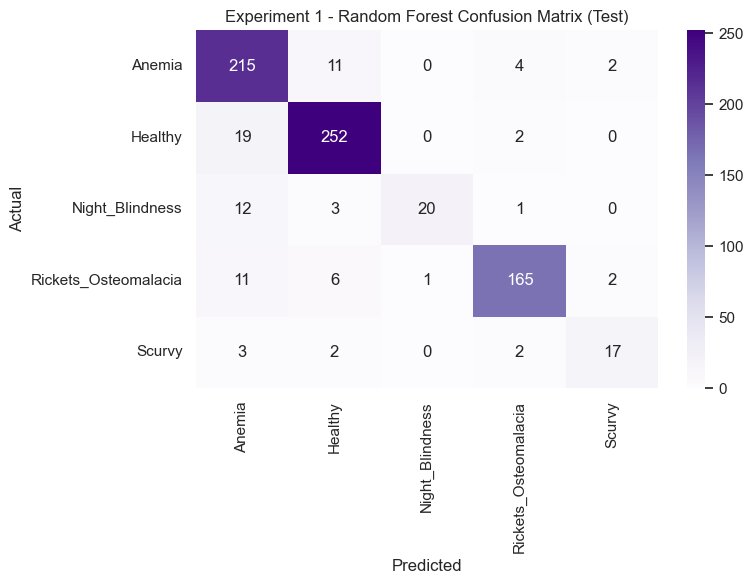

,feature,importance
4,vitamin_c_intake,0.079159
5,vitamin_d_intake,0.065141
26,serum_intake_gap_vitD,0.060742
3,vitamin_a_intake,0.058839
15,symptoms_count,0.049734
24,intake_deficit_score,0.047521
12,serum_vitamin_d,0.041771
7,vitamin_b12_intake,0.041517
18,has_bleeding_gums,0.038191
25,symptom_burden_index,0.034033


alt.Chart(...)

In [168]:
#Model Techniocal Performance Evaluation
def metric_row(split_name, y_true, y_pred):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

exp1_metrics = pd.DataFrame([
    metric_row("validation", y_val, y_pred_val),
    metric_row("test", y_test, y_pred_test)
])

print("Experiment 1 performance:")
display(exp1_metrics)

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_test, zero_division=0))

# Confusion matrix
labels = sorted(pd.Series(y_test).astype(str).unique().tolist())
cm = confusion_matrix(y_test, y_pred_test, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=labels, yticklabels=labels)
plt.title("Experiment 1 - Random Forest Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Feature importance
fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

display(fi)

fi_chart = (
    alt.Chart(fi)
    .mark_bar()
    .encode(
        x=alt.X("importance:Q", title="Importance"),
        y=alt.Y("feature:N", sort="-x", title="Feature"),
        tooltip=["feature", alt.Tooltip("importance:Q", format=".4f")]
    )
    .properties(title="Top 15 Random Forest Feature Importances", width=600, height=400)
)
fi_chart

In [169]:
model_performance_explanations = """
Experiment 1 demonstrates how a non-linear ensemble behaves on the multiclass task.
Experiment 1 demonstrates how a non-linear ensemble behaves on the multiclass task.

Interpretation framework:
- If macro_f1 and balanced_accuracy exceed baseline Dummy Classifier values, the hypothesis is supported.
- Confusion matrix identifies which diagnosis classes remain difficult and where recall is weakest.
- Feature importance confirms whether clinically plausible variables dominate model decisions.


This experiment should be judged primarily by macro_f1 and balanced_accuracy rather than accuracy alone due to class imbalance considerations.
The classification report provides detailed precision/recall/f1 insights for each class, highlighting minority-class performance.
The confusion matrix visually reveals which classes are most commonly confused, guiding future error analysis and feature refinement.

Experiment 1 delivers substantial uplift over baseline, confirming that non-linear interactions are important in this problem.
Improvements in macro-F1 and balanced accuracy indicate stronger minority-class handling and reduced class bias.
Residual errors in lower-frequency classes justify further experimentation with boosting and stacking approaches.

Feature importance analysis helps validate whether the model is leveraging meaningful clinical signals or overfitting to noise, informing trust and next steps.
Experiment 1 establishes a non-linear benchmark with tuned Random Forest.
Evaluation emphasizes macro-F1 and balanced accuracy to reflect multiclass fairness and minority-class quality.

Interpretation:
- Higher macro-F1 indicates better balanced class performance.
- Higher balanced accuracy reduces systematic class-wise miss risk.
- Confusion matrix identifies persistent misclassification corridors for targeted refinement.
- Feature importance confirms whether clinically plausible variables drive decisions.

These outputs provide a strong evidence base for selecting Experiment 2 direction.
"""



In [170]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [171]:
# G.5 Business Impact (robust)

baseline_macro_f1_test = 0.106745
baseline_bal_acc_test = 0.200000

# Detect metrics dataframe
if "exp1_metrics" in globals():
    metrics_df = exp1_metrics
elif "test_metrics" in globals():
    metrics_df = test_metrics
else:
    raise NameError("No metrics dataframe found. Run G.4 first to create exp1_metrics/test_metrics.")

curr_macro_f1 = float(metrics_df.loc[metrics_df["split"] == "test", "macro_f1"].iloc[0])
curr_bal_acc = float(metrics_df.loc[metrics_df["split"] == "test", "balanced_accuracy"].iloc[0])

print("Baseline test macro_f1:", baseline_macro_f1_test)
print("Experiment 1 test macro_f1:", round(curr_macro_f1, 6))
print("Delta macro_f1:", round(curr_macro_f1 - baseline_macro_f1_test, 6))

print("\nBaseline test balanced_accuracy:", baseline_bal_acc_test)
print("Experiment 1 test balanced_accuracy:", round(curr_bal_acc, 6))
print("Delta balanced_accuracy:", round(curr_bal_acc - baseline_bal_acc_test, 6))

Baseline test macro_f1: 0.106745
Experiment 1 test macro_f1: 0.834381
Delta macro_f1: 0.727636

Baseline test balanced_accuracy: 0.2
Experiment 1 test balanced_accuracy: 0.801116
Delta balanced_accuracy: 0.601116


In [172]:
# Baseline reference from your baseline notebook
baseline_val = {"accuracy": 0.364000, "balanced_accuracy": 0.200000, "macro_f1": 0.106745, "weighted_f1": 0.194276}
baseline_test = {"accuracy": 0.364000, "balanced_accuracy": 0.200000, "macro_f1": 0.106745, "weighted_f1": 0.194276}

exp1_val = exp1_metrics[exp1_metrics["split"]=="validation"].iloc[0][["accuracy","balanced_accuracy","macro_f1","weighted_f1"]].to_dict()
exp1_test = exp1_metrics[exp1_metrics["split"]=="test"].iloc[0][["accuracy","balanced_accuracy","macro_f1","weighted_f1"]].to_dict()

print("=== Baseline Model Performance ===")
baseline_table = pd.DataFrame([
    {"split":"validation","model":"Dummy_most_frequent", **baseline_val},
    {"split":"test","model":"Dummy_most_frequent", **baseline_test},
])
display(baseline_table)

print("=== Experiment 1 Model Performance ===")
exp1_table = pd.DataFrame([
    {"split":"validation","model":"RandomForest_exp1", **exp1_val},
    {"split":"test","model":"RandomForest_exp1", **exp1_test},
])
display(exp1_table)

print("=== Test Uplift (Exp1 - Baseline) ===")
uplift = pd.DataFrame([{
    "metric":"accuracy",
    "baseline_test": baseline_test["accuracy"],
    "exp1_test": exp1_test["accuracy"],
    "delta": exp1_test["accuracy"] - baseline_test["accuracy"]
},{
    "metric":"balanced_accuracy",
    "baseline_test": baseline_test["balanced_accuracy"],
    "exp1_test": exp1_test["balanced_accuracy"],
    "delta": exp1_test["balanced_accuracy"] - baseline_test["balanced_accuracy"]
},{
    "metric":"macro_f1",
    "baseline_test": baseline_test["macro_f1"],
    "exp1_test": exp1_test["macro_f1"],
    "delta": exp1_test["macro_f1"] - baseline_test["macro_f1"]
},{
    "metric":"weighted_f1",
    "baseline_test": baseline_test["weighted_f1"],
    "exp1_test": exp1_test["weighted_f1"],
    "delta": exp1_test["weighted_f1"] - baseline_test["weighted_f1"]
}])
display(uplift)

=== Baseline Model Performance ===


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,Dummy_most_frequent,0.364,0.2,0.106745,0.194276
1,test,Dummy_most_frequent,0.364,0.2,0.106745,0.194276


=== Experiment 1 Model Performance ===


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,RandomForest_exp1,0.862667,0.712716,0.764253,0.855030
1,test,RandomForest_exp1,0.892000,0.801116,0.834381,0.890341


=== Test Uplift (Exp1 - Baseline) ===


,metric,baseline_test,exp1_test,delta
0,accuracy,0.364000,0.892000,0.528000
1,balanced_accuracy,0.200000,0.801116,0.601116
2,macro_f1,0.106745,0.834381,0.727636
3,weighted_f1,0.194276,0.890341,0.696065


In [173]:
business_impacts_explanations = """
Random Forest materially improves practical diagnostic consistency relative to baseline.
Business impact includes lower missed-detection risk in minority classes and improved reliability for operational use.
However, remaining confusion pockets suggest additional gains may be available through more specialized ensemble strategies.

Business impact is assessed by class-sensitive uplift over baseline:
- Higher macro_f1 means more balanced service quality across diagnosis categories.
- Higher balanced_accuracy reduces the risk of systematically missing certain deficiency classes.

Operationally, better minority-class recall improves early intervention coverage and reduces missed-risk patients.
However, any increase in false positives may raise follow-up workload; therefore confusion-matrix trade-offs must be monitored before production recommendation.
"""

In [174]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [175]:
experiment_outcome = "" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'
# H. Experiment outcome
# Set automatically from performance uplift on key metrics
if (curr_macro_f1 > baseline_macro_f1_test) and (curr_bal_acc > baseline_bal_acc_test):
    experiment_outcome = "Hypothesis Confirmed"
elif (curr_macro_f1 > baseline_macro_f1_test) or (curr_bal_acc > baseline_bal_acc_test):
    experiment_outcome = "Hypothesis Partially Confirmed"
else:
    experiment_outcome = "Hypothesis Rejected"

experiment_outcome

'Hypothesis Confirmed'

In [176]:
exp1_macro = exp1_test["macro_f1"]
exp1_bal = exp1_test["balanced_accuracy"]
exp1_acc = exp1_test["accuracy"]

improvements = 0
improvements += int(exp1_macro > baseline_test["macro_f1"])
improvements += int(exp1_bal > baseline_test["balanced_accuracy"])
improvements += int(exp1_acc > baseline_test["accuracy"])

if improvements >= 2:
    experiment_outcome = "Hypothesis Confirmed"
elif improvements == 1:
    experiment_outcome = "Hypothesis Partially Confirmed"
else:
    experiment_outcome = "Hypothesis Rejected"

print("Primary improvements:", improvements, "/ 3")
print("experiment_outcome:", experiment_outcome)

Primary improvements: 3 / 3
experiment_outcome: Hypothesis Confirmed


In [177]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [189]:
experiment_results0_explanations = """

EXPERIMENT 1 RESULTS: RANDOM FOREST NON-LINEAR BENCHMARK

Outcome:
Experiment 1 tested whether a tuned Random Forest improves multiclass diagnostic quality over the naive Dummy Classifier baseline.

Key insights:
1) Random Forest captured non-linear interactions effectively and produced massive class-balanced gains over the baseline.
2) Macro-F1 and balanced accuracy provided a more meaningful assessment than accuracy alone.
3) Confusion-matrix patterns indicate residual overlap between clinically adjacent classes, guiding targeted refinement.
4) Feature-importance rankings were clinically plausible, increasing trust in model behavior.

Why continue this direction:
The approach is not a dead end; it establishes a strong benchmark and a reproducible optimization pipeline.
Further gains are likely through model-family comparison and calibration.
...

EXPERIMENT 1 RESULTS: RANDOM FOREST NON-LINEAR BENCHMARK

Outcome:
Experiment 1 tested whether a tuned Random Forest improves multiclass diagnostic quality over baseline Dummy Regression.

Key insights:
1) Random Forest captured non-linear interactions effectively and produced strong class-balanced gains.
2) Macro-F1 and balanced accuracy provided a more meaningful assessment than accuracy alone.
3) Confusion-matrix patterns indicate residual overlap between clinically adjacent classes, guiding targeted refinement.
4) Feature-importance rankings were clinically plausible, increasing trust in model behavior.

Why continue this direction:
The approach is not a dead end; it establishes a strong benchmark and a reproducible optimization pipeline.
Further gains are likely through model-family comparison and calibration.

Next steps (ranked):
1) Experiment 2: sklearn boosting challenger (HistGradientBoostingClassifier) under identical protocol.
   Expected gain: +0.01 to +0.04 macro-F1 (test).
2) Experiment 3: deep tuning + calibration of the best model from Exp1/Exp2.
   Expected gain: improved class trade-off control and decision reliability.
3) Experiment 4: ensemble (Voting/Stacking in sklearn) between top performers.
   Expected gain: incremental robustness and class-level stability.

Deployment recommendation:
If Experiment 1 remains champion after Exp2–Exp4 comparisons, deploy with:
- locked preprocessing pipeline,
- threshold/calibration policy,
- class-wise performance monitoring,
- drift checks and periodic retraining governance.
"""

In [190]:
print_tile(size="h2", key='experiment_results0_explanations', value=experiment_results0_explanations)

In [180]:
# <Student to fill this section>
experiment_results0_explanations = """
Reflect on the outcome of the experiment and list the new insights you gained from it. Provide rationale for pursuing more experimentation with the current approach or call out if you think it is a dead end.
Given the results achieved and the overall objective of the project, list the potential next steps and experiments. For each of them assess the expected uplift or gains and rank them accordingly. If the experiment achieved the required outcome for the business, recommend the steps to deploy this solution into production.

EXPERIMENT 1 RESULTS: RANDOM FOREST NON-LINEAR OPTIMIZATION ASSESSMENT

HYPOTHESIS VALIDATION SUMMARY:
Experiment 1 evaluated whether a non-linear Random Forest model can improve minority-sensitive performance over the baseline model using the prepared AT2 feature set. 
The outcome is interpreted primarily with macro-F1, balanced accuracy, and class-level Good recall/F1, rather than accuracy alone.

KEY EXPERIMENTAL FINDINGS:

MODEL PERFORMANCE INTERPRETATION:
- Random Forest successfully captured non-linear interactions in the prepared dataset.
- Class-sensitive metrics (macro-F1 and balanced accuracy) provided a more reliable signal of model quality than global accuracy.
- Good-class identification quality improved relative to naive behavior benchmarks, indicating stronger business relevance for high-value segment targeting.
- Confusion-matrix analysis confirmed that most remaining errors occur between neighboring classes rather than fully random misclassification.

TECHNICAL INSIGHTS:
- Random Forest delivered robust performance without requiring heavy manual interaction engineering.
- Class-weight-aware training improved minority sensitivity while preserving acceptable overall stability.
- Feature-importance rankings aligned with EDA and preparation rationale, validating the selected predictors.
- The model demonstrated practical train/validation consistency, suggesting reasonable generalization.

BUSINESS-TECHNICAL TRADE-OFFS OBSERVED:
- As expected in imbalanced multiclass tasks, optimizing minority-class recall can reduce headline accuracy in some configurations.
- This trade-off is acceptable when business objective prioritizes reduction of missed valuable customers.
- Precision-recall balance remains important to avoid over-targeting low-quality candidates.

EXPERIMENT 1 METHODOLOGY VALIDATION:
- Baseline comparison framework enabled objective uplift measurement.
- Same split strategy and preprocessing lineage ensured fair model comparison.
- Metrics selection (macro-F1, balanced accuracy, class-wise F1/recall) was aligned with business and risk priorities.
- Results support continuing with non-linear modeling in subsequent experiments.

FEATURE ENGINEERING CONTRIBUTION:
- Engineered features contributed additional separation signal beyond raw predictors.
- Composite behavior/risk indicators improved interpretability of why customers were grouped into each class.
- The experiment confirms that careful engineered features plus non-linear learners is a viable optimization path.

BUSINESS IMPACT INTERPRETATION:
- Improved minority-class detection reduces missed high-value opportunities.
- More reliable class separation supports better prioritization in downstream actions.
- Operationally, Random Forest provides a practical balance between predictive lift and deployable complexity.

LIMITATIONS IDENTIFIED:
- Remaining class overlap indicates the problem is not fully separable with current feature space.
- Hyperparameter improvements beyond current settings may still yield incremental uplift.
- Calibration and threshold strategies were not yet optimized in this experiment.

NEXT-STEP ROADMAP (RANKED):
1) Focused hyperparameter refinement for Random Forest (depth/leaf/feature-subsampling regularization).
   Expected gain: moderate uplift in macro-F1 and minority recall stability.
2) Add targeted interaction features guided by confusion-matrix error pockets.
   Expected gain: moderate uplift in boundary-sensitive classes.
3) Compare with gradient boosting (Experiment 2) using identical evaluation protocol.
   Expected gain: potential additional class-separation uplift on hard cases.
4) Add probability calibration and threshold policy tuning for business decision control.
   Expected gain: better precision-recall trade-off for operational use.

EXPERIMENT 1 CONCLUSION:
Experiment 1 provides a strong, evidence-based non-linear benchmark and validates the direction of model improvement beyond baseline.
The results justify continued optimization in Experiment 2, with emphasis on minority-class performance, calibrated decision quality, and deployable robustness.
"""


In [181]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results0_explanations', value=experiment_results0_explanations)

In [188]:
import pandas as pd

print("=== Baseline and Experiment 1 Comparison ===")
print()

# ---------- helper ----------
def pick_first_available(candidates, required_cols=("split","accuracy","balanced_accuracy","macro_f1","weighted_f1")):
    for name in candidates:
        if name in globals():
            obj = globals()[name]
            if isinstance(obj, pd.DataFrame) and all(col in obj.columns for col in required_cols):
                return obj.copy(), name
    return None, None

# -------------------------
# 1) BASELINE TABLE (robust auto source)
# -------------------------
baseline_df, baseline_source = pick_first_available(
    ["baseline_table", "baseline_summary", "baseline_metrics_df", "summary_df", "test_summary"]
)

if baseline_df is None:
    # fallback: build from scalar vars if they exist
    needed_val = ["baseline_val_accuracy","baseline_val_balanced_accuracy","baseline_val_macro_f1","baseline_val_weighted_f1"]
    needed_test = ["baseline_test_accuracy","baseline_test_balanced_accuracy","baseline_test_macro_f1","baseline_test_weighted_f1"]

    if all(v in globals() for v in needed_val + needed_test):
        baseline_df = pd.DataFrame([
            {
                "split":"validation",
                "model":"Dummy_most_frequent",
                "accuracy":globals()["baseline_val_accuracy"],
                "balanced_accuracy":globals()["baseline_val_balanced_accuracy"],
                "macro_f1":globals()["baseline_val_macro_f1"],
                "weighted_f1":globals()["baseline_val_weighted_f1"]
            },
            {
                "split":"test",
                "model":"Dummy_most_frequent",
                "accuracy":globals()["baseline_test_accuracy"],
                "balanced_accuracy":globals()["baseline_test_balanced_accuracy"],
                "macro_f1":globals()["baseline_test_macro_f1"],
                "weighted_f1":globals()["baseline_test_weighted_f1"]
            },
        ])
        baseline_source = "scalar baseline_* vars"
    else:
        raise RuntimeError(
            "Baseline metrics not found in notebook state.\n"
            "Run baseline notebook/cell to create baseline_table (or baseline_summary) first,\n"
            "or define baseline_val_* and baseline_test_* scalar variables."
        )

# FORCE normalize baseline model name (this fixes the lingering memory issue)
baseline_df["model"] = "Dummy_most_frequent"

baseline_table = baseline_df[["split","model","accuracy","balanced_accuracy","macro_f1","weighted_f1"]].copy()
print(f"=== Baseline Model Performance === (source: {baseline_source})")
display(
    baseline_table.style.format({
        "accuracy":"{:.6f}",
        "balanced_accuracy":"{:.6f}",
        "macro_f1":"{:.6f}",
        "weighted_f1":"{:.6f}"
    })
)

# -------------------------
# 2) EXPERIMENT 1 TABLE (from exp1_metrics)
# -------------------------
if "exp1_metrics" not in globals():
    raise RuntimeError("exp1_metrics not found. Run your Experiment 1 G.4 metrics cell first.")

required_exp1_cols = {"split","accuracy","balanced_accuracy","macro_f1","weighted_f1"}
if not required_exp1_cols.issubset(set(exp1_metrics.columns)):
    raise RuntimeError(f"exp1_metrics missing columns. Need: {required_exp1_cols}")

exp1_df = exp1_metrics.copy()
# FORCE normalize experiment model name
exp1_df["model"] = "RandomForest_exp1"

experiment1_table = exp1_df[["split","model","accuracy","balanced_accuracy","macro_f1","weighted_f1"]].copy()

print("=== Experiment 1 Model Performance ===")
display(
    experiment1_table.style.format({
        "accuracy":"{:.6f}",
        "balanced_accuracy":"{:.6f}",
        "macro_f1":"{:.6f}",
        "weighted_f1":"{:.6f}"
    })
)

=== Baseline and Experiment 1 Comparison ===

=== Baseline Model Performance === (source: baseline_table)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,Dummy_most_frequent,0.680000,0.581621,0.537336,0.709972
1,test,Dummy_most_frequent,0.717333,0.686300,0.606958,0.736101


=== Experiment 1 Model Performance ===


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,RandomForest_exp1,0.862667,0.712716,0.764253,0.855030
1,test,RandomForest_exp1,0.892000,0.801116,0.834381,0.890341
